## Adding Hyperbolic Layer to DynoV3 ViT-L/16 distilled

### Set up

In [ ]:
import pickle
import os
import urllib

import numpy as np
from matplotlib.patches import ConnectionPatch
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from tqdm import tqdm

import torch.nn as nn


from PIL import Image
import torch
import torchvision.transforms as T

import torch
from dinov3.models.vision_transformer import vit_large

import torchvision

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans



DINOv3 location set to facebookresearch/dinov3


### Model loading

In [ ]:

# create the model
model = vit_large(patch_size=16, num_register_tokens=0)

# load weights manually
state_dict = torch.load(
    "/home/carmenoliver/my_projects/dynov3-testing-stuff/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth",
    map_location="cpu"
)
model.load_state_dict(state_dict, strict=False)
model.cuda()
model.eval()

Ignored kwargs: {'num_register_tokens': 0}


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-23): 24 x SelfAttentionBlock(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): Identity()
    )
  )
  (norm): LayerNorm((10

### Data loading k

In [ ]:
# import os
# import rasterio
# import numpy as np
# from PIL import Image
# from pathlib import Path

# # --- CONFIGURATION ---

# DATA_ROOT = Path("/data/databases/SSL4EO-S12/ssl4eo-s12/s2a")
# OUTPUT_IMAGES_DIR = Path.cwd() / "processed_images"

# if not DATA_ROOT.is_dir():
#     print("--- ERROR ---")
#     print(f"Input directory does NOT exist or is inaccessible: {DATA_ROOT}")
#     print("Please update the 'DATA_ROOT' variable in the script to the correct absolute path on your system.")
#     print("-----------------")
#     exit()

# # Create the output directory relative to your current project folder
# OUTPUT_IMAGES_DIR.mkdir(exist_ok=True)
# print(f"Input data is located at: {DATA_ROOT}")
# print(f"Output images will be saved to: {OUTPUT_IMAGES_DIR}")

# # --- PROCESSING LOOP ---
# processed_count = 0
# skipped_count = 0

# <!-- # Loop through the files inside the DATA_ROOT directory -->
# <!-- for tile_path in DATA_ROOT.iterdir():
#     # Only process directories (which represent the tiles/timestamp)
#     if not tile_path.is_dir(): continue

#     # Loop through timestamp directories inside the tile directory
#     for ts_path in tile_path.iterdir():
#         if not ts_path.is_dir(): continue
        
#         try:
#             # 1. Check for required bands (B4, B3, B2)
#             band_files = [ts_path / f"B{b}.tif" for b in [4, 3, 2]]
#             if not all(f.exists() for f in band_files):
#                 raise FileNotFoundError("Missing one or more required band files (B2, B3, B4).")

#             # 2. Read the bands using rasterio
#             bands = [rasterio.open(f).read(1) for f in band_files]
            
#             # 3. Apply color correction and clipping (your original logic)
#             # Clip values to the 99th percentile of the Red band (B4) for contrast
#             percentile_99 = np.percentile(bands[0], 99)
#             rgb = np.clip(np.stack(bands, -1), 0, percentile_99)
            
#             # Normalize to 0-255 range and convert to unsigned 8-bit integer
#             # Use the max value of the clipped array to normalize
#             rgb = (rgb / rgb.max() * 255).astype(np.uint8)
            
#             # 4. Define output filename and save
#             # The name is generated from the tile and timestamp directory names
#             output_filename = f"{tile_path.name}_{ts_path.name}.jpg"
#             Image.fromarray(rgb).save(OUTPUT_IMAGES_DIR / output_filename)
#             processed_count += 1

#         except Exception as e:
#             skipped_count += 1
#             print(f"Skipping {ts_path.name} → Error: {e}")

# print("\n--- ✅ Processing Complete ---")
# print(f"Processed images saved to: {OUTPUT_IMAGES_DIR.resolve()}")
# print(f"Processed: {processed_count} files.")
# print(f"Skipped:   {skipped_count} files (check the log above for details).") 

In [20]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torchvision.transforms as T

transform = T.Compose([
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),   # converts to [0,1] float32
    # Optional: normalize to 0 mean, 1 std if you know dataset stats
    # T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # scales to [-1,1]
])

class ImageFolderDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.img_paths = [os.path.join(img_dir, f) for f in os.listdir(img_dir)
                          if f.lower().endswith((".jpg", ".png"))]
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img
    
img_dir = "/home/carmenoliver/my_projects/processed_images"

dataset = ImageFolderDataset(img_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=40, shuffle=True)

### Adding Hyperbolic layer embeding with loss

In [ ]:
for param in model.parameters():
    param.requires_grad = False
    
import torch

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# Get one batch AND move it to the device
image_batch = next(iter(dataloader)) 
image_batch = image_batch.to(device)

# Run inference
with torch.no_grad():
    features = model(x=image_batch)

print(f"Features tensor shape: {features.shape}")
print(f"Features tensor is on device: {features.device}")


Using device: cuda
Features tensor shape: torch.Size([40, 1024])
Features tensor is on device: cuda:0


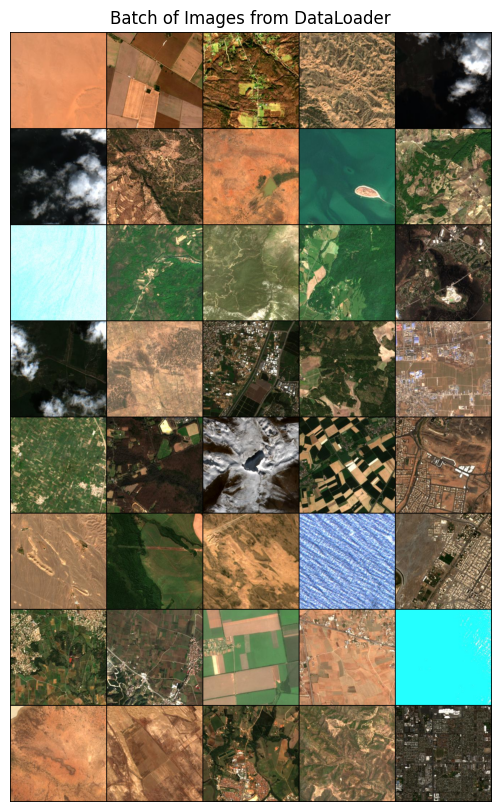

In [ ]:
#VISUALIZING IMAGES

images_cpu = image_batch.cpu()

# Make grid (normalize=False keeps original pixel values)
grid = torchvision.utils.make_grid(images_cpu, nrow=5, padding=2)

# Convert CHW -> HWC for matplotlib
npimg = grid.permute(1, 2, 0).numpy()

plt.figure(figsize=(10,10))
plt.imshow(npimg)
plt.axis("off")
plt.title("Batch of Images from DataLoader")
plt.show()

In [ ]:
def exp_map(v, c=1.0, eps=1e-5):
    norm_v = torch.norm(v, dim=-1, keepdim=True)  

    return torch.tanh(torch.sqrt(torch.tensor(c)) * norm_v) * v / (norm_v + eps)

emb_normed = F.normalize(features, dim=-1)
hyperbolic_embeddings = exp_map(emb_normed, c=1.0)

hyperbolic_embeddings.shape

torch.Size([40, 1024])

## Visualization of Euclidean Embedings and Hyperbolic Embedings 

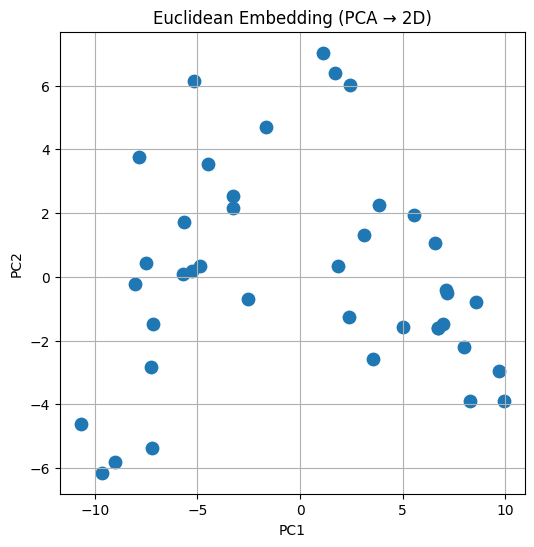

In [24]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(features.detach().cpu().numpy())

plt.figure(figsize=(6,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], s=80)
plt.title("Euclidean Embedding (PCA → 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

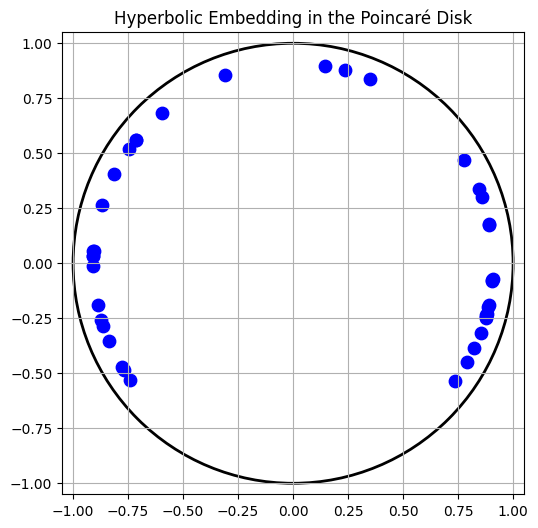

In [25]:
hyp_2d = pca.fit_transform(hyperbolic_embeddings.detach().cpu().numpy())

# normalize to stay inside unit disk
norms = torch.norm(torch.tensor(hyp_2d), dim=-1, keepdim=True)
hyp_2d_scaled = hyp_2d / (norms * 1.1)   # shrink slightly so max radius < 1

fig, ax = plt.subplots(figsize=(6,6))

# draw unit circle
circle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=2)
ax.add_artist(circle)

# scatter points
plt.scatter(hyp_2d_scaled[:,0], hyp_2d_scaled[:,1], s=80, color='blue')

plt.title("Hyperbolic Embedding in the Poincaré Disk")
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()

In [ ]:
k = 3  # arbitrary
kmeans_euc = KMeans(n_clusters=k).fit(emb_2d)
sil_euc = silhouette_score(emb_2d, kmeans_euc.labels_)

kmeans_hyp = KMeans(n_clusters=k).fit(hyp_2d_scaled)
sil_hyp = silhouette_score(hyp_2d_scaled, kmeans_hyp.labels_)

print("Silhouette Euclidean:", sil_euc)
print("Silhouette Hyperbolic:", sil_hyp)

Silhouette Euclidean: 0.5134495496749878
Silhouette Hyperbolic: 0.6479835510253906


In [72]:
query_idx = 11 # first image in your batch
query_emb = features[query_idx:query_idx+1]  # Euclidean
query_hyp = hyperbolic_embeddings[query_idx:query_idx+1]  # Hyperbolic

In [73]:
from sklearn.metrics.pairwise import cosine_similarity

sims = cosine_similarity(query_emb.cpu(), features.cpu())[0]  # similarity to all images
topk = sims.argsort()[::-1][:5]  # 5 most similar images

from scipy.spatial.distance import cdist
dists = cdist(query_hyp.cpu().numpy(), hyperbolic_embeddings.cpu().numpy(), metric='euclidean')[0]
topk_hyp_v1 = dists.argsort()[:5]  # 5 closest points

print(topk)
print(topk_hyp_v1)



[11 20 13 21  9]
[11 20 13 21  9]


### Train twicked model

In [74]:
for param in model.parameters():
    param.requires_grad = False

import torch.nn as nn
import torch.nn.functional as F

class HyperbolicHead(nn.Module):
    def __init__(self, in_dim, out_dim, c=1.0):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.c = c
        
    def forward(self, x):
        x = self.linear(x)
        # Exponential map to Poincaré ball
        norm = torch.norm(x, dim=-1, keepdim=True)
        x_hyp = torch.tanh(torch.sqrt(torch.tensor(self.c)) * norm) * x / (norm + 1e-5)
        return x_hyp

def mobius_add(u, v, c=1.0):
    # Möbius addition in Poincaré ball
    u2 = (u**2).sum(dim=-1, keepdim=True)
    v2 = (v**2).sum(dim=-1, keepdim=True)
    uv = (u * v).sum(dim=-1, keepdim=True)
    numerator = (1 + 2*c*uv + c*v2)*u + (1 - c*u2)*v
    denominator = 1 + 2*c*uv + c**2 * u2 * v2
    return numerator / (denominator + 1e-5)

def poincare_distance(u, v, c=1.0):
    diff = mobius_add(-u, v, c)
    norm = diff.norm(dim=-1, keepdim=True)
    return 2 / torch.sqrt(torch.tensor(c)) * torch.atanh(torch.clamp(torch.sqrt(torch.tensor(c))*norm, max=1-1e-5))

# Example: batch of hyperbolic embeddings
# pos_pairs: list of (i,j) indices of positive pairs
def hyperbolic_contrastive_loss(hyp_emb, pos_pairs, margin=1.0):
    loss = 0.0
    for i,j in pos_pairs:
        d = poincare_distance(hyp_emb[i:i+1], hyp_emb[j:j+1])
        loss += d**2  # pull positives together
    return loss / len(pos_pairs)


In [75]:
in_dim = features.shape[1]   # usually 1024 for DINOv3
out_dim = 128                # embedding dimension in hyperbolic space
c = 1.0                      # curvature

hyp_head = HyperbolicHead(in_dim, out_dim, c=c)
hyp_head.train()

HyperbolicHead(
  (linear): Linear(in_features=1024, out_features=128, bias=True)
)

In [76]:
device = features.device  # get the device of your features
hyp_head = HyperbolicHead(in_dim, out_dim, c=c).to(device)
hyp_emb = hyp_head(features)

In [77]:
from sklearn.metrics.pairwise import cosine_similarity

# cosine similarity in Euclidean space
sims = cosine_similarity(features.cpu())
num_pos = 3  # how many neighbors per image to treat as positives

pos_pairs = []
for i in range(sims.shape[0]):
    # sort indices of neighbors (excluding self)
    neighbors = sims[i].argsort()[::-1]
    neighbors = [j for j in neighbors if j != i][:num_pos]
    for j in neighbors:
        pos_pairs.append((i,j))

In [78]:
loss = hyperbolic_contrastive_loss(hyp_emb, pos_pairs)
print("Hyperbolic loss:", loss.item())

import torch.optim as optim

optimizer = optim.Adam(hyp_head.parameters(), lr=1e-3)

# Example single training step
optimizer.zero_grad()
hyp_emb = hyp_head(features)   # forward
loss = hyperbolic_contrastive_loss(hyp_emb, pos_pairs)
loss.backward()
optimizer.step()

Hyperbolic loss: 66.16548919677734


[11 20 13  9 21]


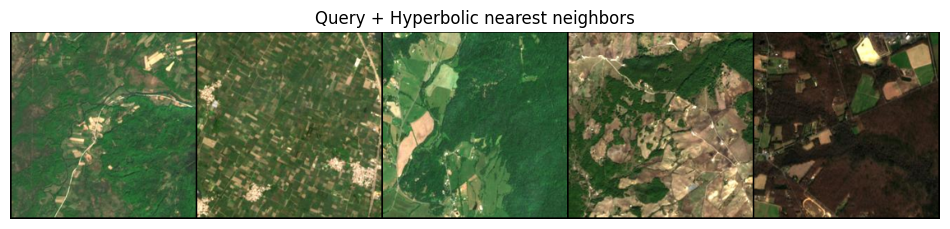

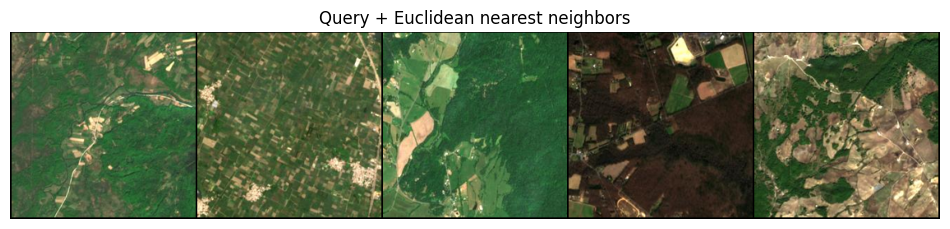

In [79]:
from scipy.spatial.distance import cdist

dists = cdist(hyp_emb[query_idx:query_idx+1].detach().cpu().numpy(),
              hyp_emb.detach().cpu().numpy(), metric='euclidean')[0]
topk_hyp = dists.argsort()[:5]  # closest neighbors
print(topk_hyp)

def show_selected_images(batch, indices, nrow=None, title=""):
    """
    batch: full image batch tensor [B,C,H,W]
    indices: list or tensor of image indices to display
    nrow: number of images per row in the grid (default: all in one row)
    """
    # Step 1: select the images
    selected = batch[indices]           # shape: [len(indices), C,H,W]
    
    # Step 2: CPU, clone to avoid strides issues
    selected = selected.detach().cpu().float().clone()
    
    # Step 3: make grid
    if nrow is None:
        nrow = len(indices)
    grid = torchvision.utils.make_grid(selected, nrow=nrow, padding=2)
    
    # Step 4: convert to NumPy safely
    npimg = grid.permute(1,2,0).contiguous().numpy().copy()
    
    # Step 5: plot
    plt.figure(figsize=(12,3))
    plt.imshow(npimg)
    plt.axis("off")
    plt.title(title)
    plt.show()

show_selected_images(image_batch, [query_idx]+[i for i in topk_hyp if i != query_idx],
                     title="Query + Hyperbolic nearest neighbors")


show_selected_images(image_batch, [query_idx]+[i for i in topk if i != query_idx],
                     title="Query + Euclidean nearest neighbors")



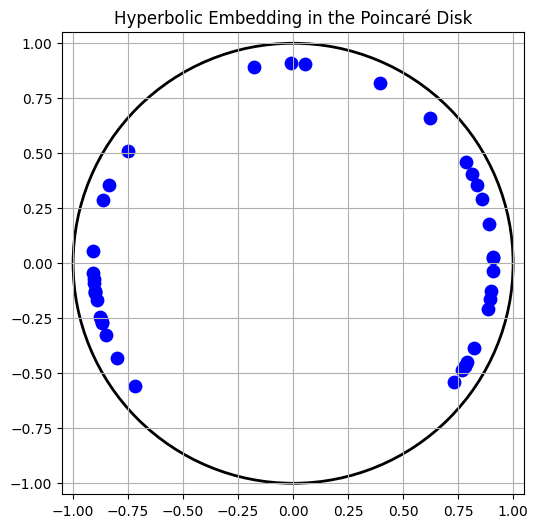

In [80]:
hyp_2d = pca.fit_transform(hyp_emb.detach().cpu().numpy())

# normalize to stay inside unit disk
norms = torch.norm(torch.tensor(hyp_2d), dim=-1, keepdim=True)
hyp_2d_scaled = hyp_2d / (norms * 1.1)   # shrink slightly so max radius < 1

fig, ax = plt.subplots(figsize=(6,6))

# draw unit circle
circle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=2)
ax.add_artist(circle)

# scatter points
plt.scatter(hyp_2d_scaled[:,0], hyp_2d_scaled[:,1], s=80, color='blue')

plt.title("Hyperbolic Embedding in the Poincaré Disk")
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()